#  Group 2 Sentiment Analysis: New Sentiment approach

###  **DSBA 6165: AI & Deep Learning**
### Group Member: Paul Berlin, Anders Pierson, Roberto Panameno

## Proc4 Goal

The original dataset had a sentiment field in it. We will be removing that field and creating a sentiment model from scratch.

## Uploading Training and Validation Dataset

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing Dataset
datatot = pd.read_csv('/content/twitter_combined_nosentiment.csv')

In [ ]:
datatot.head(5)

,tweet_id,entity,tweet_content
0,2401,Borderlands,im getting on borderlands and i will murder yo...
1,2401,Borderlands,I am coming to the borders and I will kill you...
2,2401,Borderlands,im getting on borderlands and i will kill you ...
3,2401,Borderlands,im coming on borderlands and i will murder you...
4,2401,Borderlands,im getting on borderlands 2 and i will murder ...


## Data Preprocessing

In [ ]:
import re
import pandas as pd

def clean_text(text):
    text = str(text) # Ensure the input is a string
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove user mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters, keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

# Group by tweet_id and other relevant identifiers (entity) and concatenate the original 'tweet_content' for each unique group.
grouped_datatot = datatot.groupby(['tweet_id', 'entity'])['tweet_content'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

# Apply the clean_text function to the newly concatenated 'tweet_content'
grouped_datatot['cleaned_tweet_content'] = grouped_datatot['tweet_content'].apply(clean_text)

# Replace the original datatot DataFrame with this new, grouped and cleaned version.
datatot = grouped_datatot

print("Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id' and 'entity'.")
print("Displaying the first 5 rows with the new 'cleaned_tweet_content' column:")
datatot.head()

Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id' and 'entity'.
Displaying the first 5 rows with the new 'cleaned_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...


## Tokenize Text

In [ ]:
datatot['tokenized_tweet_content'] = datatot['cleaned_tweet_content'].apply(lambda x: x.split())

print("Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:")
datatot.head()

Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content,tokenized_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today..."
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though..."
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser..."
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ..."


## Remove Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
print("NLTK stopwords corpus downloaded.")

NLTK stopwords corpus downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

datatot['filtered_tweet_content'] = datatot['tokenized_tweet_content'].apply(remove_stopwords)

print("Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:")
datatot.head()

Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,..."
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t..."


## Lemmatize Text

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK 'wordnet' and 'omw-1.4' corpora downloaded.")

NLTK 'wordnet' and 'omw-1.4' corpora downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

datatot['lemmatized_tweet_content'] = datatot['filtered_tweet_content'].apply(lemmatize_tokens)

print("Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:")
datatot.head()

Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ..."
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim..."


## Build Vocabulary and Encode Text

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Join the lemmatized tokens back into strings for the tokenizer
datatot['lemmatized_text_string'] = datatot['lemmatized_tweet_content'].apply(lambda x: ' '.join(x))

# Initialize tokenizer, considering a vocabulary size and OOV token
# The num_words parameter determines the maximum number of words to keep, based on word frequency.
# oov_token handles words not found in the vocabulary during text_to_sequence conversion.
tokenizer = Tokenizer(num_words=10000, oov_token='<unk>') # Adjust num_words as needed

# Fit tokenizer on the lemmatized text strings to build the vocabulary
tokenizer.fit_on_texts(datatot['lemmatized_text_string'])

# Convert text to sequences of integers
datatot['encoded_tweet_content'] = tokenizer.texts_to_sequences(datatot['lemmatized_text_string'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:")
datatot.head()

Vocabulary size: 34797
Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]"
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length for padding
# Using the 95th percentile to avoid extremely long sequences affecting all others
sequence_lengths = [len(seq) for seq in datatot['encoded_tweet_content']]
max_sequence_length = int(np.percentile(sequence_lengths, 95)) # Use 95th percentile for max length

# Pad sequences to the chosen maximum length
padded_sequences = pad_sequences(
    datatot['encoded_tweet_content'],
    maxlen=max_sequence_length,
    padding='post', # Pad with zeros at the end
    truncating='post' # Truncate from the end if sequence is longer than maxlen
)

print(f"Maximum sequence length (95th percentile): {max_sequence_length}")
print(f"Shape of padded sequences: {padded_sequences.shape}")

# You can add the padded sequences back to the DataFrame if needed,
# but often they are used directly for model input
datatot['padded_tweet_content'] = list(padded_sequences)

print("Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:")
datatot.head()

Maximum sequence length (95th percentile): 150
Shape of padded sequences: (12447, 150)
Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:


,tweet_id,entity,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content,padded_tweet_content
0,1,Amazon,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]","[167, 42, 167, 42, 167, 167, 167, 55, 167, 0, ..."
1,2,Amazon,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328...","[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,...","[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22...","[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1...","[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Lexicon-based Sentiment Scoring

1.  **Defining Lexicons**: Creating lists of words associated with positive and negative sentiments.
2.  **Scoring Function**: Developing a function to count positive and negative words in a given text.
3.  **Applying to Data**: Using this function to assign a sentiment score to each `tweet_content` entry.

In [ ]:
# Define expanded positive and negative word lexicons with graded scores
positive_lexicon = {
    'good': 1, 'great': 2, 'excellent': 2,'dope': 2, 'amazing': 2, 'happy': 1, 'love': 1.5,
    'like': 1, 'awesome': 2, 'best': 2, 'fantastic': 2, 'superb': 2, 'lmao': 1.5,
    'wonderful': 2, 'joy': 1.5, 'pleasure': 1, 'beautiful': 1.5, 'perfect': 2,
    'brilliant': 2, 'outstanding': 2, 'delight': 1.5, 'enjoy': 1, 'win': 1.5,
    'success': 1.5, 'positive': 1, 'favorite': 1.5, 'cheer': 1.5, 'glorious': 2,
    'lucky': 1.5, 'haha': 1, 'lol': 1, 'yay': 1, 'hooray': 1.5, 'victory': 2, 'top': 1.5,
    'agree': 0.8, 'recommend': 1, 'fun': 1.2, 'exciting': 1.8, 'gorgeous': 1.5, 'impressive': 1.5
}
negative_lexicon = {
    'bad': -1,'insult': -1,'dying': -1,'dead': -1, 'terrible': -2, 'horrible': -2, 'awful': -2, 'hate': -1.5,
    'disappointing': -1.5, 'worst': -2, 'poor': -1, 'frustrating': -1.5,
    'shit': -2, 'fuck': -3, 'damn': -1.5,'goddamn': -1.5, 'wft': -1, 'suck': -1.5, 'fail': -1.5,
    'ugly': -1, 'annoying': -1, 'sad': -1.5, 'miserable': -2, 'unhappy': -1.5,
    'anger': -1.5, 'stress': -1, 'bored': -1, 'pathetic': -1.5, 'lame': -1,
    'ruin': -1.5, 'offensive': -1.5, 'crap': -1, 'nightmare': -2, 'stupid': -1.5,
    'waste': -1.5, 'unacceptable': -2, 'problem': -1.2, 'issue': -0.8, 'slow': -0.7,
    'bug': -1.3, 'broken': -2, 'scam': -2.5, 'rip-off': -2, 'disgusting': -2,
    'crisis': -2.5, 'danger': -2, 'threat': -2, 'fail': -1.5, 'idiot': -1.8, 'liar': -1.5,
    'fake': -1.5, 'mistake': -1, 'regret': -1.2, 'sick': -1.5, 'pain': -1.8,
    '😡': -2, '😠': -2, '😤': -2, '😭': -2, '😩': -1.8, '🤦‍♀️': -1.5, '👎': -2, '💔': -2.5, '🤬': -3
}

# Define negation words and intensifiers/de-intensifiers
negation_words = ['not', 'no', 'never', 'don', 't', 'can', 'won', 'isn', 'wasn', 'didn', 'wouldn', 'couldn', 'nt', 'none', 'hardly', 'barely'] # Simplified 'don't' etc. to their root in lemmatized text
intensifier_words = {'very': 1.5, 'extremely': 1.8, 'really': 1.3, 'so': 1.2, 'much': 1.2, 'super': 1.4, 'highly': 1.3, 'utterly': 1.7}
deintensifier_words = {'slightly': 0.7, 'a little': 0.5, 'barely': 0.3, 'hardly': 0.3, 'somewhat': 0.6, 'kind of': 0.5}

def improved_lexicon_sentiment_score(text):
    score = 0
    words = text.split()

    for i, word in enumerate(words):
        current_word_sentiment = 0
        sentiment_multiplier = 1.0
        is_negated = False

        # Check for negation in preceding words (up to 3 words back)
        for neg_idx in range(max(0, i-3), i):
            if words[neg_idx] in negation_words:
                is_negated = True
                break

        # Check for intensifiers/de-intensifiers in preceding words (up to 2 words back)
        for intensity_idx in range(max(0, i-2), i):
            prev_word = words[intensity_idx]
            if prev_word in intensifier_words:
                sentiment_multiplier *= intensifier_words[prev_word]
            elif prev_word in deintensifier_words:
                sentiment_multiplier *= deintensifier_words[prev_word]

        if word in positive_lexicon:
            current_word_sentiment = positive_lexicon[word]
        elif word in negative_lexicon:
            current_word_sentiment = negative_lexicon[word]

        if current_word_sentiment != 0:
            if is_negated:
                current_word_sentiment *= -1 # Flip the sentiment if negated
            score += current_word_sentiment * sentiment_multiplier # Apply intensity multiplier

    return score

# Apply the improved sentiment scoring function to the lemmatized text
datatot['sentiment_score'] = datatot['lemmatized_text_string'].apply(improved_lexicon_sentiment_score)

# Categorize sentiment based on the score with adjusted thresholds
def categorize_sentiment(score):
    positive_threshold = 0.5  # Score must be above this to be positive
    negative_threshold = -0.5 # Score must be below this to be negative

    if score > positive_threshold:
        return 'Positive'
    elif score < negative_threshold:
        return 'Negative'
    else:
        return 'Neutral'

datatot['lexicon_sentiment'] = datatot['sentiment_score'].apply(categorize_sentiment)

print("Improved lexicon-based sentiment scoring complete. Displaying a random sample of 5 rows with new sentiment columns:")
print(datatot[['lemmatized_text_string', 'sentiment_score', 'lexicon_sentiment']].sample(5))

Improved lexicon-based sentiment scoring complete. Displaying a random sample of 5 rows with new sentiment columns:
                                  lemmatized_text_string  sentiment_score  \
11359  sure data going frustrated kid using immediate...              0.0   
5497   grudgingly eating healthy snack water break in...              0.0   
8186   guy gotta get chris smoove k manager commentat...              1.5   
4839   tell affect people view sex worker gang violen...              0.0   
8558   thats wack mic player player instead thats wac...              0.0   

      lexicon_sentiment  
11359           Neutral  
5497            Neutral  
8186           Positive  
4839            Neutral  
8558            Neutral  


/tmp/ipykernel_1421/163700901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lexicon_sentiment', data=datatot, palette='viridis')


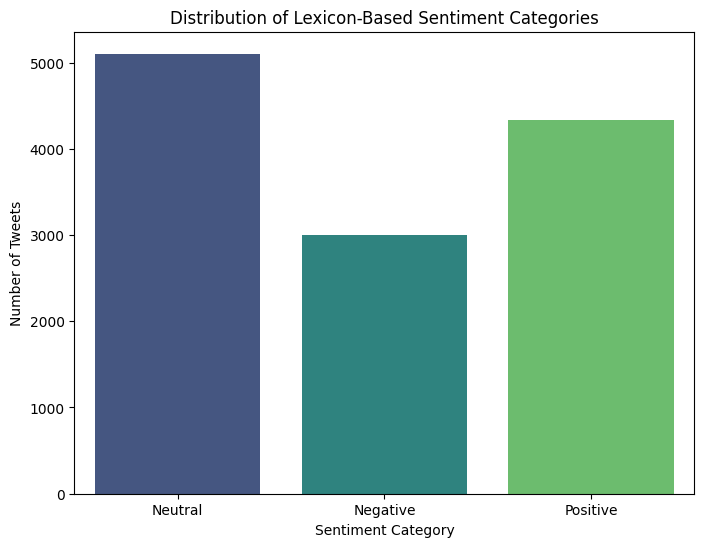

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='lexicon_sentiment', data=datatot, palette='viridis')
plt.title('Distribution of Lexicon-Based Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Tweets')
plt.show()

## Build the CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Model Parameters
vocabulary_size = len(tokenizer.word_index) + 1 # +1 for padding/0 index
embedding_dim = 128 # Dimension of the word embeddings
filters = 128 # Number of filters for the Conv1D layer
kernel_size = 5 # Size of the convolutional kernel
output_classes = y_train.shape[1] # Number of sentiment categories (e.g., 3 for Negative, Neutral, Positive)
input_length = max_sequence_length # Length of input sequences after padding

# Build the 1D CNN Model
model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=input_length),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(), # Reduces output to 2D
    Dropout(0.5),
    Dense(units=32, activation='relu'),
    Dropout(0.5),
    Dense(units=output_classes, activation='softmax') # Softmax for multi-class classification
])

# Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the 1D CNN Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
batch_size = 32
epochs = 50 # EarlyStopping will handle when to stop

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Train the model with EarlyStopping
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping], # Add the callback here
    verbose=1
)

print("\nModel training complete (with Early Stopping).")

Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7290 - loss: 0.6422 - val_accuracy: 0.9627 - val_loss: 0.1605
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9581 - loss: 0.1609 - val_accuracy: 0.9671 - val_loss: 0.1035
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9704 - loss: 0.1041 - val_accuracy: 0.9635 - val_loss: 0.1056
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9770 - loss: 0.0836 - val_accuracy: 0.9582 - val_loss: 0.1218
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9811 - loss: 0.0705 - val_accuracy: 0.9655 - val_loss: 0.1142
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9843 - loss: 0.0574 - val_accuracy: 0.9586 - val_loss: 0.1295
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9864 - loss: 0.0466 - val_accuracy: 0.9546 - val_loss: 0.1536
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.

Model training comp

## Plot Training and Validation Curves

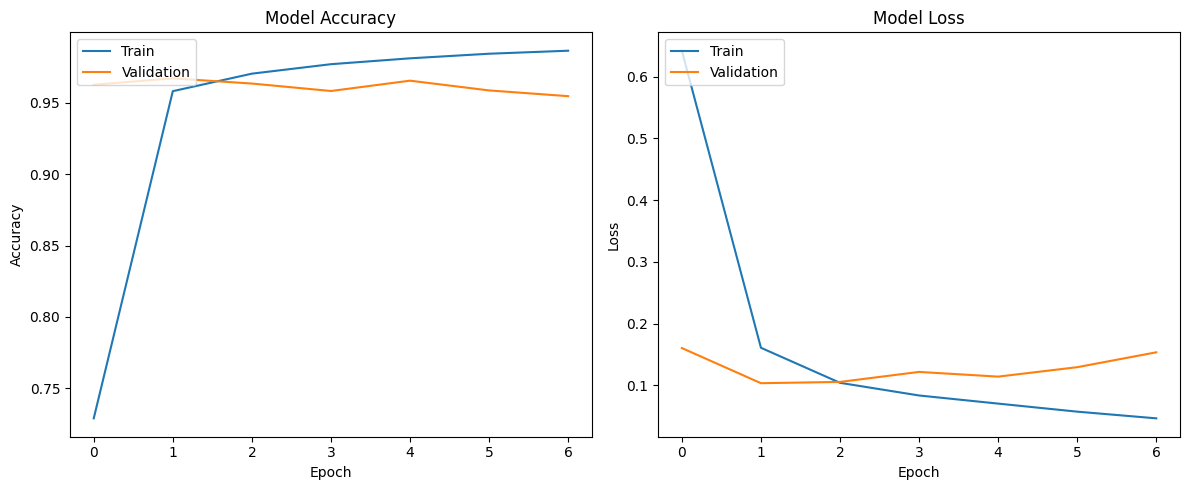

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## Evaluate Model Performance

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


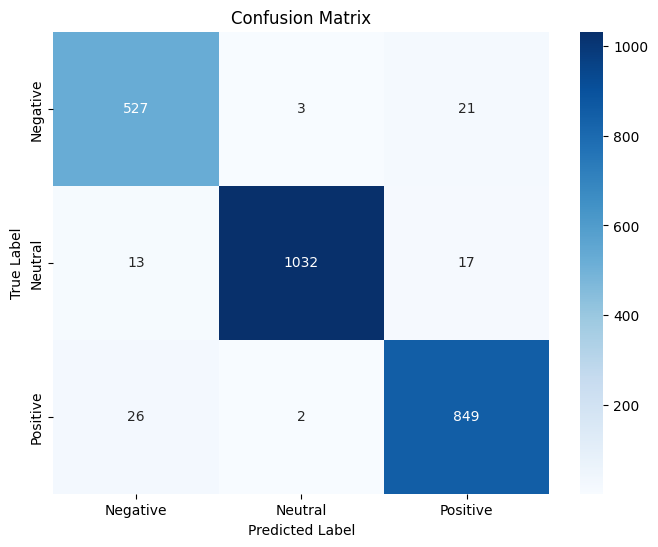


Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.94       551
     Neutral       1.00      0.97      0.98      1062
    Positive       0.96      0.97      0.96       877

    accuracy                           0.97      2490
   macro avg       0.96      0.97      0.96      2490
weighted avg       0.97      0.97      0.97      2490



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities on the validation set
y_pred_proba = model.predict(X_val)

# Convert predicted probabilities to class labels
y_pred_labels = np.argmax(y_pred_proba, axis=1)

# Convert true one-hot encoded labels to class labels
y_true_labels = np.argmax(y_val, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Get class names from label_encoder
class_names = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))


**Export misclassified comments**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ensure datatot is available and has 'lexicon_sentiment' column
if 'datatot' not in locals():
    raise ValueError("DataFrame 'datatot' not found. Please ensure it's loaded and processed.")

# Get the original indices of the full datatot DataFrame
original_datatot_indices = datatot.index.values

# Perform the train-test split on the indices to mimic the original split
_, val_indices_split, _, _ = train_test_split(
    np.arange(len(datatot)), # Split indices from 0 to len(datatot)-1
    datatot['lexicon_sentiment'], # Use lexicon_sentiment for stratification
    test_size=0.2,
    random_state=42,
    stratify=datatot['lexicon_sentiment']
)

# Identify misclassified samples using the previously computed y_true_labels and y_pred_labels
misclassified_mask = (y_true_labels != y_pred_labels)

# Get the original indices from datatot corresponding to the misclassified validation samples
original_misclassified_indices = val_indices_split[misclassified_mask]

# Retrieve the misclassified comments from the original datatot DataFrame
misclassified_data = datatot.loc[original_misclassified_indices].copy() # .copy() to avoid SettingWithCopyWarning

# Add true and predicted sentiment labels to the DataFrame
misclassified_data['true_sentiment'] = [class_names[label] for label in y_true_labels[misclassified_mask]]
misclassified_data['predicted_sentiment'] = [class_names[label] for label in y_pred_labels[misclassified_mask]]

# Rename 'tweet_content' for clarity in the output to distinguish it from cleaned/lemmatized versions
misclassified_data.rename(columns={'tweet_content': 'original_tweet_content'}, inplace=True)

# Select relevant columns for the exportable list
export_columns = [
    'tweet_id',
    'entity',
    'original_tweet_content',
    'true_sentiment',
    'predicted_sentiment',
    'sentiment_score',
    'lexicon_sentiment',
    'cleaned_tweet_content',
    'lemmatized_text_string'
]

misclassified_export = misclassified_data[export_columns]

print(f"Found {len(misclassified_export)} misclassified comments in the validation set.")
print("Displaying the first 5 misclassified comments:")
print(misclassified_export.head())

# To save the list to a CSV file (uncomment the lines below to enable)
output_filename = 'misclassified_comments_list.csv'
misclassified_export.to_csv(output_filename, index=False)
print(f"\nMisclassified comments saved to '{output_filename}'")

Found 82 misclassified comments in the validation set.
Displaying the first 5 misclassified comments:
       tweet_id                             entity  \
4064       4173                              CS-GO   
9788      10071  PlayerUnknownsBattlegrounds(PUBG)   
6437       6647                           Fortnite   
10502     10827               TomClancysGhostRecon   
9156       9414                          Overwatch   

                                  original_tweet_content true_sentiment  \
4064   Loving the changes @CSGO pic.twitter.com/JzT2H...       Negative   
9788   Me tOo.  I do. Me tOo. Me Both. Me a tOo. <unk...        Neutral   
6437   THE MASTIFF IS BROKEN !. LINK - youtu.be/AzuYJ...        Neutral   
10502  Ghost Recon Wildlands is still so epic!. New v...        Neutral   
9156   .@TPAIN.... . Come @PlayOverwatch with some of...        Neutral   

      predicted_sentiment  sentiment_score lexicon_sentiment  \
4064             Positive              1.5          Positi